In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import FunctionTransformer
from category_encoders import MEstimateEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import RFE
from sklearn.metrics import fbeta_score

import eli5
from sklearn.inspection import permutation_importance as sklearn_permutation_importance
import shap
from copy import deepcopy


# Get data

In [2]:
#2024
origin_2024_Q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/orig_2024Q1.txt",sep="|",header=None,low_memory=False)
perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None,low_memory=False)

#2023

origin_2023_Q4_df = pd.read_csv("historical_data_2023/historical_data_2023Q4/orig_2023Q4.txt",sep="|",header=None,low_memory=False)
perform_2023_q4_df = pd.read_csv("historical_data_2023/historical_data_2023Q4/perf_2023Q4.txt",sep="|",header=None,low_memory=False)

origin_2023_Q3_df = pd.read_csv("historical_data_2023/historical_data_2023Q3/orig_2023Q3.txt",sep="|",header=None,low_memory=False)
perform_2023_q3_df = pd.read_csv("historical_data_2023/historical_data_2023Q3/perf_2023Q3.txt",sep="|",header=None,low_memory=False)

origin_2023_Q2_df = pd.read_csv("historical_data_2023/historical_data_2023Q2/orig_2023Q2.txt",sep="|",header=None,low_memory=False)
perform_2023_q2_df = pd.read_csv("historical_data_2023/historical_data_2023Q2/perf_2023Q2.txt",sep="|",header=None,low_memory=False)

#2022

origin_2022_Q4_df = pd.read_csv("historical_data_2022/historical_data_2022Q4/orig_2022Q4.txt",sep="|",header=None,low_memory=False)
perform_2022_q4_df = pd.read_csv("historical_data_2022/historical_data_2022Q4/perf_2022Q4.txt",sep="|",header=None,low_memory=False)

In [3]:
origin_df_raw = pd.concat([origin_2023_Q2_df,origin_2023_Q3_df,origin_2023_Q4_df,origin_2024_Q1_df,origin_2022_Q4_df],axis=0,ignore_index=True)
performance_df_raw = pd.concat([perform_2023_q2_df,perform_2023_q3_df,perform_2023_q4_df,perform_2024_q1_df,perform_2022_q4_df],axis=0,ignore_index=True)

In [4]:
origination_columns = [
    "classic_fico",
    "first_payment_date",
    "first_time_homebuyer_indicator",
    "maturity_date",
    "msa_or_metropolitan_division",
    "mi_percentage",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "prepayment_penalty_indicator",
    "amortization_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_identifier",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "special_eligibility_program",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "vantagescore_4_0"
]
performance_columns = [
    "loan_identifier",
    "period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "underwriting_defect_and_major_servicing_defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_of_last_paid_installment",
    "mi_recoveries",
    "net_sales_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss",
    "cumulative_modification_costs",
    "interest_rate_step_indicator",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_plan",
    "current_period_modification_costs",
    "current_interest_bearing_upb",
    "mortgage_insurance_cancellation_indicator",
    "servicer_name",
    "bankruptcy_cramdown_costs"
]

assert len(performance_columns) == 35

origin_df_raw.columns=origination_columns
performance_df_raw.columns=performance_columns




# Preliminary

## Target table creation

In [5]:
origin_df = origin_df_raw.copy()
performance_df = performance_df_raw.copy()

In [6]:
assert origin_df["loan_identifier"].is_unique

performance_with_age = performance_df.merge(
    origin_df[
        ["loan_identifier", "first_payment_date"]
    ],
    on="loan_identifier",
    how="left",
    validate="many_to_one"
)

performance_with_age["first_payment_date_parsed"] = pd.to_datetime(
    performance_with_age["first_payment_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["period_parsed"] = pd.to_datetime(
    performance_with_age["period"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["original_loan_age"] = (
    (
        performance_with_age["period_parsed"].dt.year
        - performance_with_age["first_payment_date_parsed"].dt.year
    ) * 12
    +
    (
        performance_with_age["period_parsed"].dt.month
        - performance_with_age["first_payment_date_parsed"].dt.month
    )
    + 1
)

target_df = (
    performance_with_age.loc[
        performance_with_age["original_loan_age"].eq(20),
        [
            "loan_identifier",
            "current_loan_delinquency_status"
        ]
    ]
    .rename(
        columns={
            "current_loan_delinquency_status":
                "status_at_month_20"
        }
    )
    .reset_index(drop=True)
)

status_column = "status_at_month_20"

target_df[status_column] = (
    target_df[status_column]
    .astype("string")
    .str.strip()
    .str.upper()
)

numeric_mask = target_df[status_column].str.fullmatch(
    r"\d+"
)

target_df.loc[numeric_mask, status_column] = (
    target_df.loc[numeric_mask, status_column]
    .str.zfill(2)
)

status_numeric = pd.to_numeric(
    target_df[status_column],
    errors="coerce"
)

target_df["target_90plus"] = (
    status_numeric.ge(3)
    | target_df[status_column].eq("RA")
).astype("Int8")
unavailable_status = (
    target_df[status_column].isna()
    | target_df[status_column].eq("XX")
)

target_df.loc[
    unavailable_status,
    "target_90plus"
] = pd.NA

pd.crosstab(
    target_df[status_column],
    target_df["target_90plus"],
    dropna=False
)

target_df = target_df[
    ["loan_identifier", "target_90plus"]
].copy()

model_df = origin_df.merge(
    target_df,
    on="loan_identifier",
    how="inner",
    validate="one_to_one"
)


## Data cleaning

In [7]:
number_of_borrowers_map={
    3:2,
    4:2,
    5:2,
    6:2,
    7:2,
    8:2,
    9:2,
    10:2
}
evaluation_method_map={
    1:"appraisal waiver (ACE)",
    2:"appraisal",
    3:"other",
    4:"ACE_PDR"
}

In [8]:
model_df["classic_fico"] = model_df["classic_fico"].replace(to_replace=9999 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = model_df["first_time_homebuyer_indicator"].replace(to_replace="9" , value=np.nan)
model_df["first_time_homebuyer_indicator"] = (model_df["first_time_homebuyer_indicator"] == "Y").astype(int)
model_df["mi_percentage"] = model_df["mi_percentage"].replace(to_replace=999 , value=np.nan)
model_df["number_of_units"] = model_df["number_of_units"].replace(to_replace=99 , value=np.nan)
model_df["occupancy_status"] = model_df["occupancy_status"].replace(to_replace="9" , value=np.nan)
model_df["original_cltv"] = model_df["original_cltv"].replace(to_replace=999 , value=np.nan)
model_df["original_dti"] = model_df["original_dti"].replace(to_replace=999 , value=np.nan)
model_df["original_ltv"] = model_df["original_ltv"].replace(to_replace=999 , value=np.nan)
model_df["channel"] = model_df["channel"].replace(to_replace="9" , value=np.nan)
model_df["prepayment_penalty_indicator"] = (model_df["prepayment_penalty_indicator"] == "Y").astype(int)
model_df["property_type"] = model_df["property_type"].replace(to_replace="99" , value=np.nan)
model_df["postal_code"] = model_df["postal_code"].replace(to_replace=000 , value=np.nan)
model_df["loan_purpose"] = model_df["loan_purpose"].replace(to_replace="9" , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(to_replace=99 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(number_of_borrowers_map)
model_df["super_conforming_flag"] = (model_df["super_conforming_flag"] == "Y").astype(int)
model_df["special_eligibility_program"] = model_df["special_eligibility_program"].fillna("NONE_OR_NA")
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(to_replace=7 , value=np.nan)
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(evaluation_method_map)
first_payment_date= pd.to_datetime(
    model_df["first_payment_date"].astype("string"),
    format = "%Y%m",
    errors="coerce"
)
model_df["first_payment_date"]=first_payment_date
model_df["first_payment_month"]=first_payment_date.dt.month
maturity_date = pd.to_datetime(
    model_df["maturity_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)
model_df["effective_loan_duration"]= ((maturity_date.dt.year - first_payment_date.dt.year)*12+(maturity_date.dt.month-first_payment_date.dt.month))

del model_df["loan_identifier"]
del model_df["pre_harp_loan_sequence_number"]
del model_df["harp_indicator"]
del model_df["interest_only_indicator"]
del model_df["vantagescore_4_0"]
del model_df["maturity_date"]




## Columns creation

In [9]:
## Column division 
columns=[
    'classic_fico', 'first_time_homebuyer_indicator',
       'msa_or_metropolitan_division', 'mi_percentage', 'number_of_units',
       'occupancy_status', 'original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate', 'channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type', 'postal_code', 'loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag',
       'special_eligibility_program', 'property_valuation_method',
       'first_payment_month', "effective_loan_duration"
]
all_columns = columns + ["target_90plus"]


numerical_columns =['classic_fico','mi_percentage','original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate',]

categorical_columns=['first_time_homebuyer_indicator','msa_or_metropolitan_division','number_of_units','occupancy_status','channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type','postal_code','loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag','special_eligibility_program', 'property_valuation_method',
               'first_payment_month', "effective_loan_duration"]

# Encoding methods

one_hot_encoding_columns= [ "first_time_homebuyer_indicator","number_of_units","occupancy_status","channel","amortization_type","prepayment_penalty_indicator","property_type"
                           ,"loan_purpose","number_of_borrowers","super_conforming_flag","special_eligibility_program","property_valuation_method","first_payment_month"]
target_encoding_columns=["msa_or_metropolitan_division","property_state","postal_code",
                            "original_loan_term","seller_name","effective_loan_duration"]

model_df[categorical_columns]=model_df[categorical_columns].astype("string")
model_df[numerical_columns]=model_df[numerical_columns].astype("float64")

In [10]:
model_df

,classic_fico,first_payment_date,first_time_homebuyer_indicator,msa_or_metropolitan_division,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,original_upb,...,loan_purpose,original_loan_term,number_of_borrowers,seller_name,super_conforming_flag,special_eligibility_program,property_valuation_method,target_90plus,first_payment_month,effective_loan_duration
0,693.0,2023-07-01,1,45780.0,30.0,1,P,95.0,30.0,147000.0,...,P,360,1,OTHER,0,NONE_OR_NA,appraisal,0,7,359
1,717.0,2023-06-01,0,36420.0,25.0,1,P,87.0,45.0,259000.0,...,N,360,2,OTHER,0,NONE_OR_NA,appraisal,0,6,359
2,720.0,2023-08-01,1,31180.0,18.0,1,P,99.0,36.0,256000.0,...,P,360,2,"LAKEVIEW LOAN SERVICING, LLC",0,F,appraisal,0,8,359
3,673.0,2023-06-01,1,35004.0,30.0,1,P,95.0,43.0,322000.0,...,P,360,2,OTHER,0,NONE_OR_NA,appraisal,0,6,359
4,791.0,2023-06-01,0,15540.0,0.0,1,P,67.0,32.0,545000.0,...,N,360,1,OTHER,0,NONE_OR_NA,appraisal,0,6,359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022881,731.0,2024-07-01,0,12054.0,0.0,1,P,44.0,19.0,302000.0,...,N,360,1,OTHER,0,NONE_OR_NA,appraisal,0,7,359
1022882,791.0,2024-08-01,0,19804.0,0.0,1,P,69.0,29.0,295000.0,...,P,360,2,OTHER,0,NONE_OR_NA,appraisal,0,8,359
1022883,750.0,2024-05-01,0,48424.0,25.0,1,P,90.0,50.0,362000.0,...,N,360,2,OTHER,0,NONE_OR_NA,appraisal,0,5,359
1022884,773.0,2024-07-01,0,27260.0,0.0,1,P,38.0,35.0,315000.0,...,N,360,1,OTHER,0,NONE_OR_NA,appraisal,0,7,359


# EDA

In [11]:
model_df_eda = model_df.copy() # final data
origin_df_raw_eda = origin_df_raw.copy()
performance_df_raw_eda = performance_df_raw.copy()

## Basic exploration

In [20]:
n_loans = origin_df_raw_eda.shape[0]
print(f"Number of original loans : {n_loans}")
print(f"Number of lians with 20 month target : {model_df.shape[0]}")
print(f"Number of excluded loans : {n_loans-model_df.shape[0]} , that is {round(((n_loans-model_df.shape[0])/n_loans)*100,3)} %")

Number of original loans : 1183107
Number of lians with 20 month target : 1022886
Number of excluded loans : 160221 , that is 13.542 %


In [21]:
defective_df =  model_df.target_90plus.value_counts(dropna=False)
global_defective = model_df.target_90plus.mean() 

print(f"Non defective loans in 20 months time with a defectivness of 90+ days : {defective_df.loc[0]} \nDefective loans in 20 months time with a defectivness of 90+ days : {defective_df.iloc[1]}")
print(f"\n\nGlobal defective rate : {round(global_defective,5)} %")
print("\nThe data id highly unbalanced , this have to be taken into consideration for evaluation")

Non defective loans in 20 months time with a defectivness of 90+ days : 1014970 
Defective loans in 20 months time with a defectivness of 90+ days : 7916


Global defective rate : 0.00774 %

The data id highly unbalanced , this have to be taken into consideration for evaluation


## Analize target coverage

In [22]:
origin_df_raw_eda["has_month_20_target"]=(
    origin_df_raw_eda["loan_identifier"].isin(target_df["loan_identifier"]).astype("int8")
)

In [23]:
# What happend to those not chosen loans : evaluating bias

excluded_loans_identifier = origin_df_raw_eda.loc[origin_df_raw_eda["has_month_20_target"].eq(0),"loan_identifier"]
performance_excluded_loans = performance_df_raw_eda.loc[performance_df_raw_eda["loan_identifier"].isin(excluded_loans_identifier)].copy()

performance_excluded_loans = performance_excluded_loans.sort_values(["loan_identifier","period"]).groupby("loan_identifier").tail(1)

In [24]:
zero_balance_code_df = performance_excluded_loans["zero_balance_code"].copy()
zero_balance_map = {
    1:"voluntary payoff or maturity",
    96:"defect before event",
    2:"third-party sale",
    9:"REOdisposition",
    16:"reperforming-loan sale",
    3:"short sale/charge-off",
    15:"whole-loan sale"
}

zero_balance_code_df = zero_balance_code_df.map(zero_balance_map).fillna("Missing")
zero_balance_code_distribution = zero_balance_code_df.value_counts()
zero_balance_code_distribution

zero_balance_code
voluntary payoff or maturity    155049
defect before event               4521
Missing                            546
third-party sale                    53
REOdisposition                      32
short sale/charge-off               18
whole-loan sale                      1
reperforming-loan sale               1
Name: count, dtype: int64

Text(0, 0.5, 'Reason')

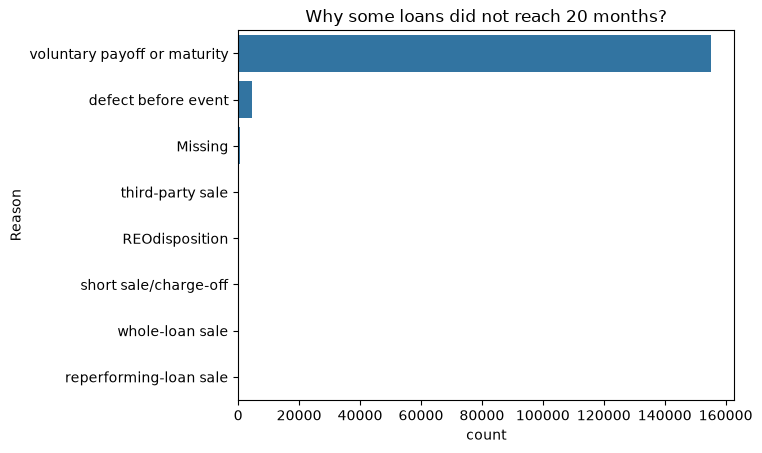

In [25]:
#sns.barplot(zero_balance_code_distribution.drop(index=["Missing"]),orient="h")
sns.barplot(zero_balance_code_distribution,orient="h")
plt.title("Why some loans did not reach 20 months?")
plt.ylabel("Reason")

In [26]:
default_events = [
    "third-party sale",
    "REOdisposition",
    "short sale/charge-off"
]
non_default_events = [
    "voluntary payoff or maturity",
    "reperforming-loan sale"
]
uncertain_events = [
    "defect before event",  
    "Missing"               
]

defaults = zero_balance_code_distribution.loc[default_events].sum()
non_default = zero_balance_code_distribution.loc[non_default_events].sum()
uncertain = zero_balance_code_distribution.loc[uncertain_events].sum()
total = zero_balance_code_df.shape[0]

print(f"Non-default loans are : {non_default} and are the {round(non_default*100/total,3)} % of non cosidered loans")
print(f"Uncertain loans are : {uncertain} and are the {round(uncertain*100/total,3)} % of non cosidered loans")
print(f"\n\nDefault loans are : {defaults} and are the {round(defaults*100/total,3)} % of non cosidered loans")
print(f"This loans are {round(defaults/n_loans,4)} % of the total loans")
print("The number of not considered default is negligible , we will continue with our data ")


Non-default loans are : 155050 and are the 96.773 % of non cosidered loans
Uncertain loans are : 5067 and are the 3.163 % of non cosidered loans


Default loans are : 103 and are the 0.064 % of non cosidered loans
This loans are 0.0001 % of the total loans
The number of not considered default is negligible , we will continue with our data 


In [27]:
print("There is no significant differenc in this features considered")
origin_df_raw_eda.groupby("has_month_20_target")[["classic_fico","original_dti","original_ltv","original_interest_rate"]].agg(["mean","std"]).T


There is no significant differenc in this features considered


has_month_20_target                   0           1
classic_fico           mean  758.199225  752.019330
                       std   211.643716  164.637291
original_dti           mean   38.046105   38.164136
                       std    10.998692   11.758921
original_ltv           mean   71.055704   76.215924
                       std    20.604149   19.037721
original_interest_rate mean    7.036443    6.683133
                       std     0.668645    0.675497

## Numerical and categorical risk

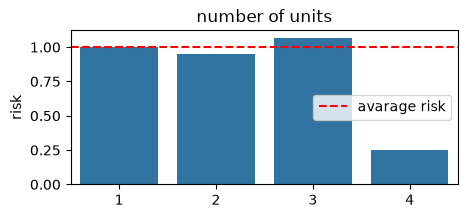

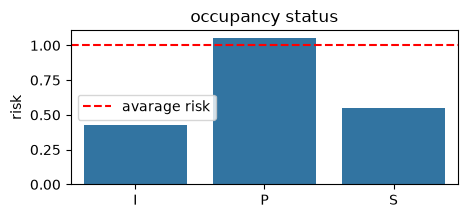

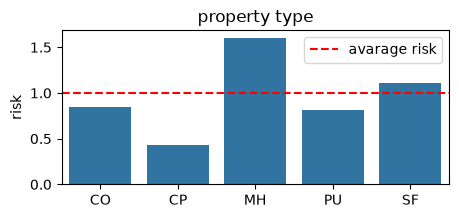

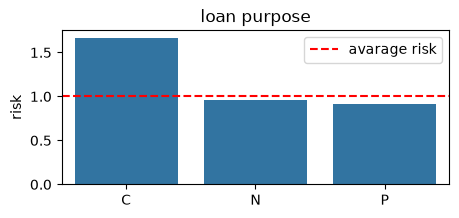

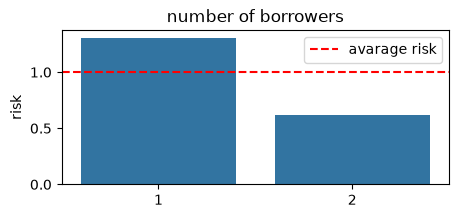

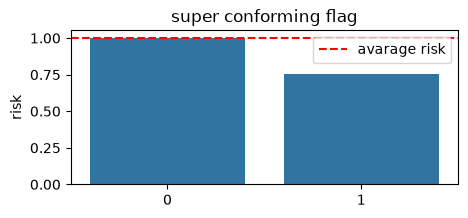

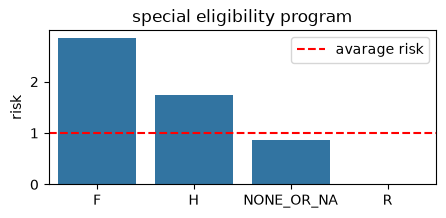

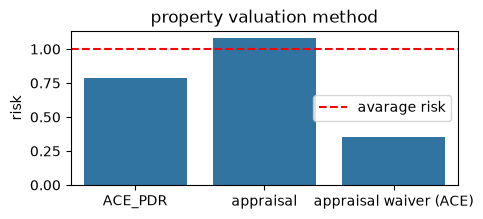

In [43]:
categorical_columns_eda = [col for col in categorical_columns if model_df_eda[col].nunique() <= 10]

for col in categorical_columns_eda:
    df = pd.DataFrame()
    df=model_df.groupby(col).target_90plus.agg(["mean","count"])
    df["risk"]=df["mean"]/global_defective

    relevant = ((df["risk"]>1.2) | (df["risk"]< 0.8))
    
    if relevant.any() :
        fig ,ax = plt.subplots(figsize=(5,2))
        sns.barplot(data = df , x=df.index,y=df.risk,ax=ax)
        ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
        plt.title(col.replace("_"," "))
        plt.xlabel(None)
        ax.legend()
        

            

    


    


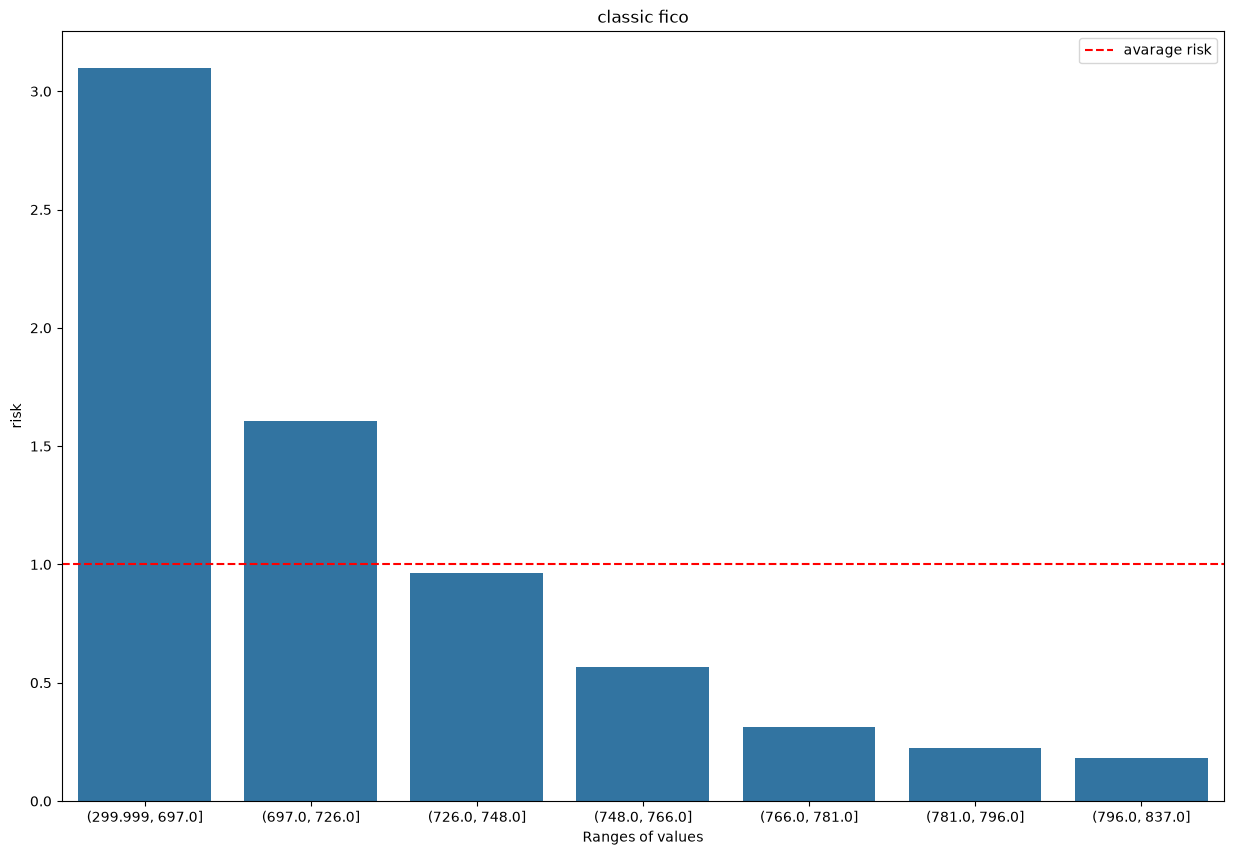

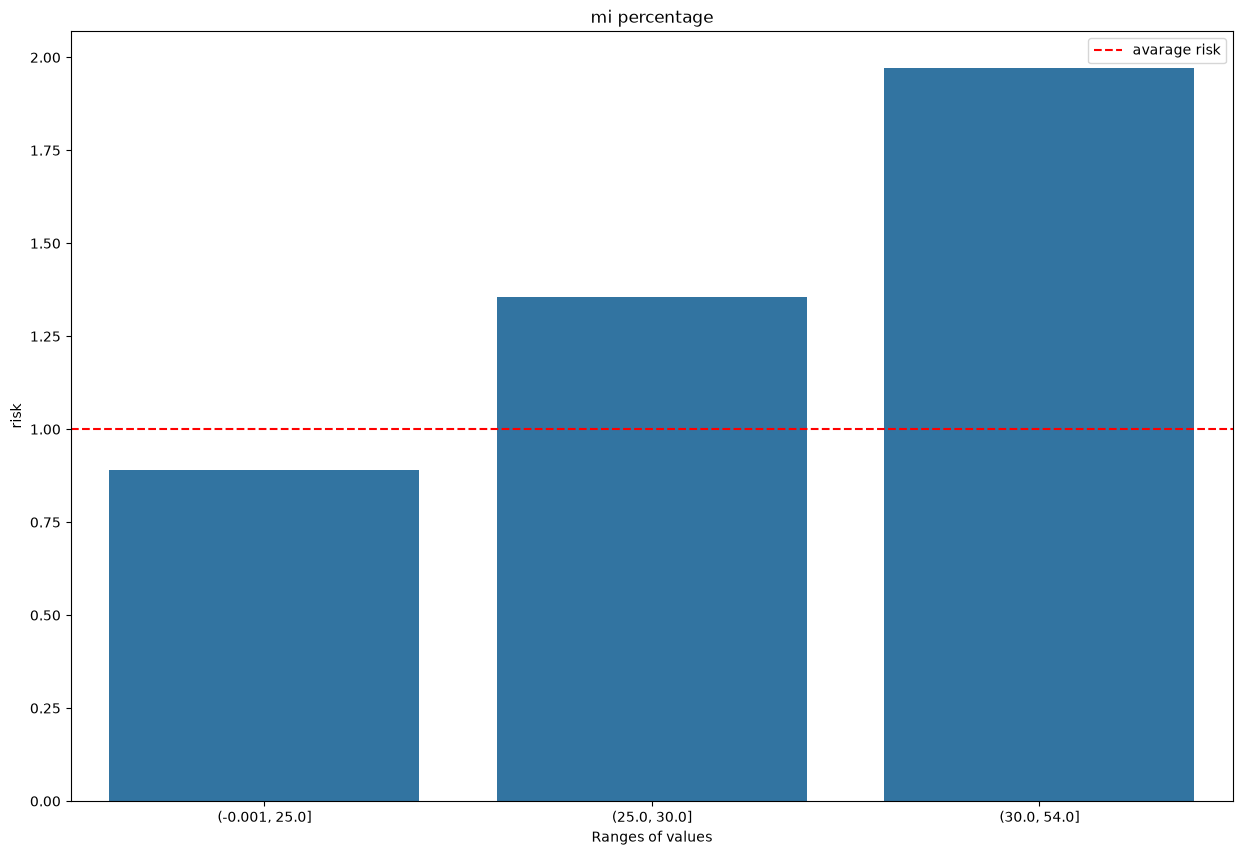

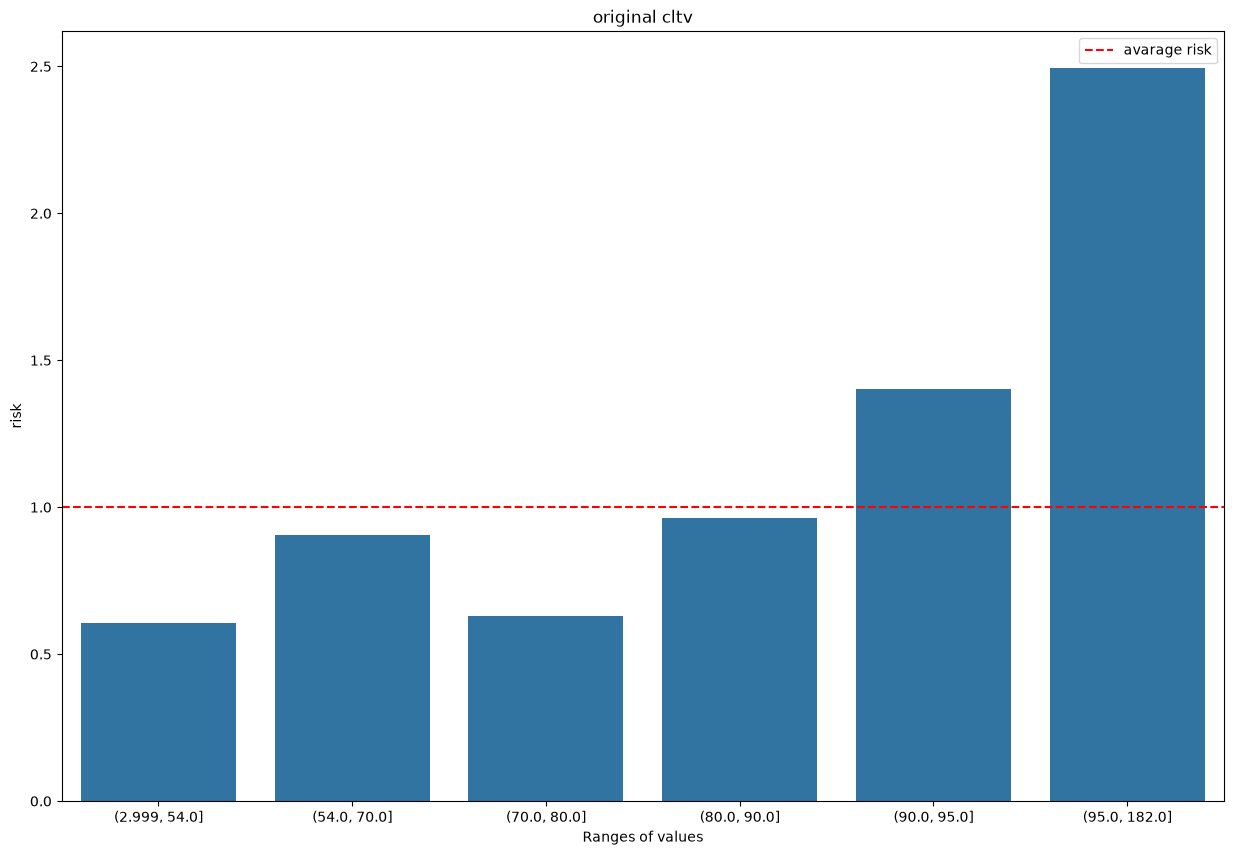

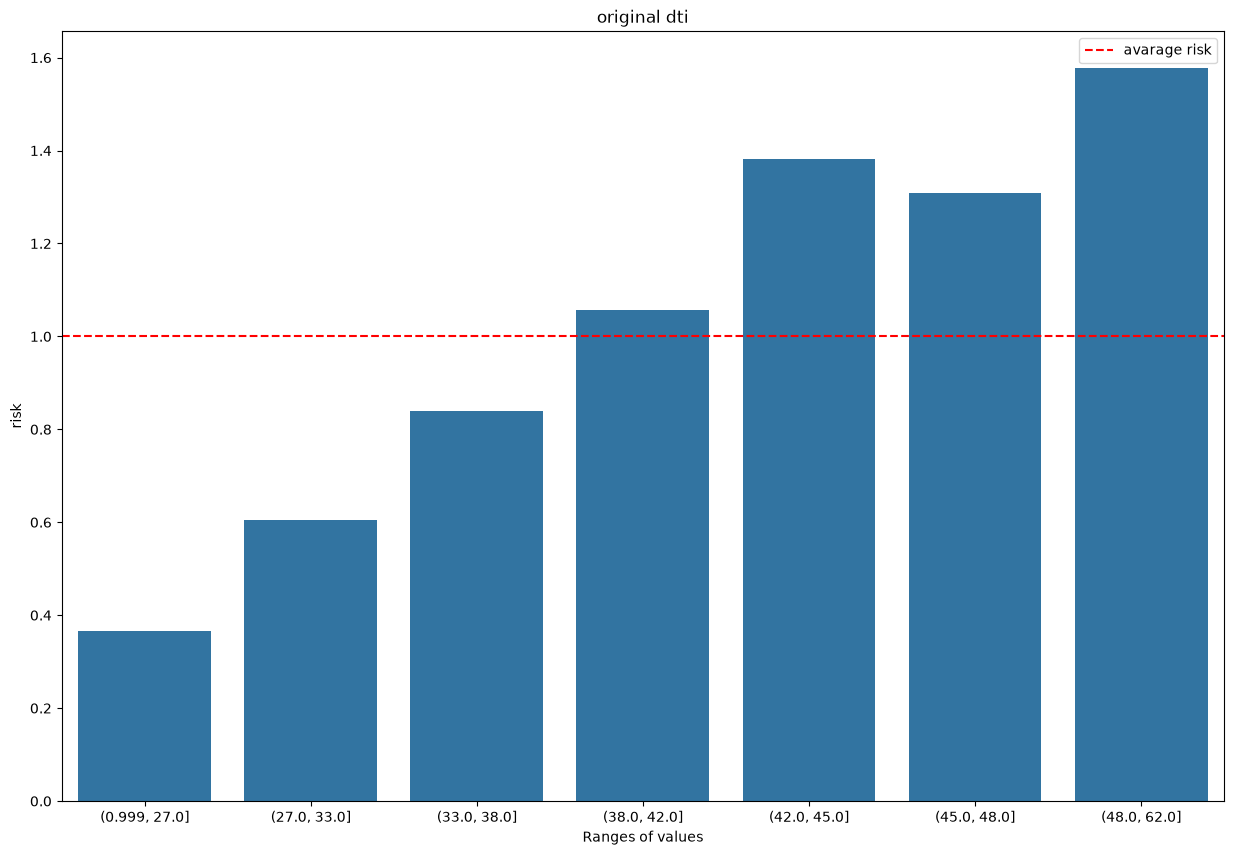

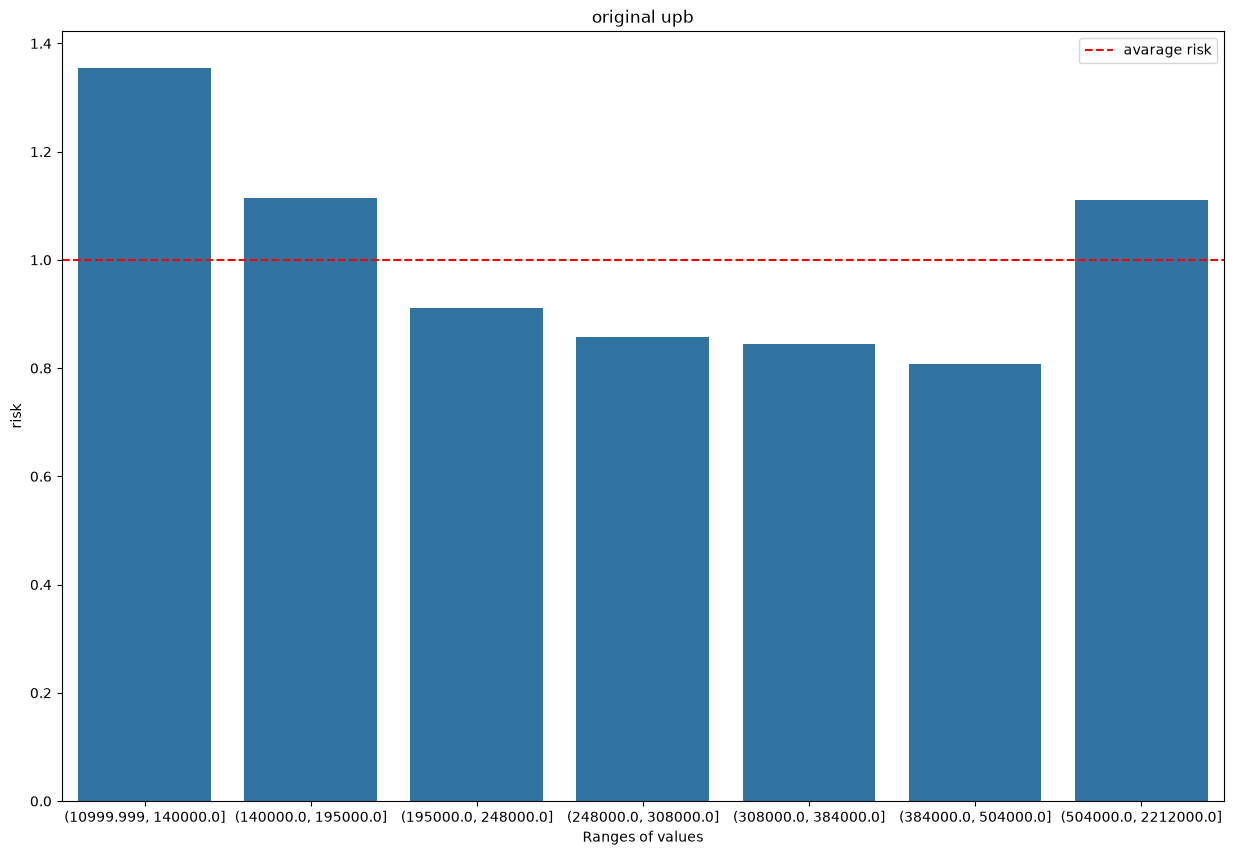

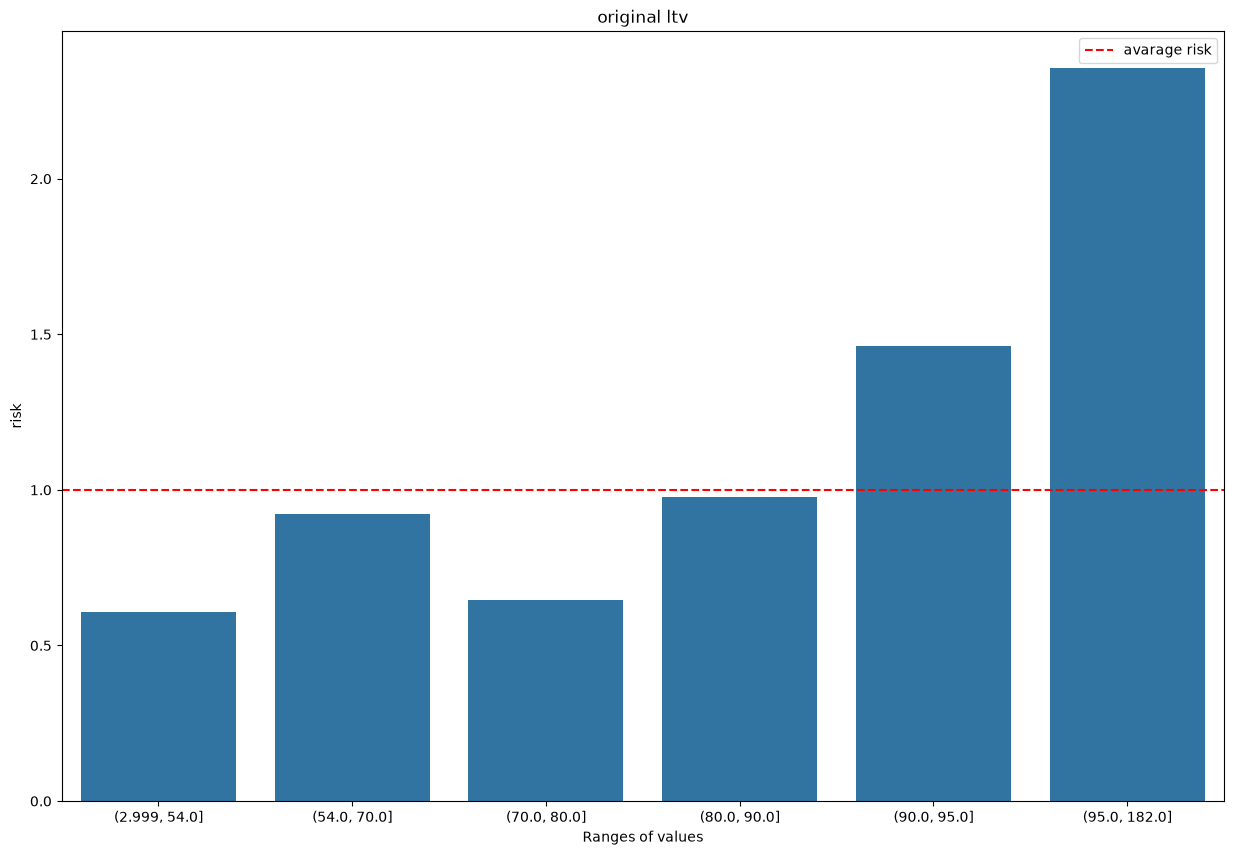

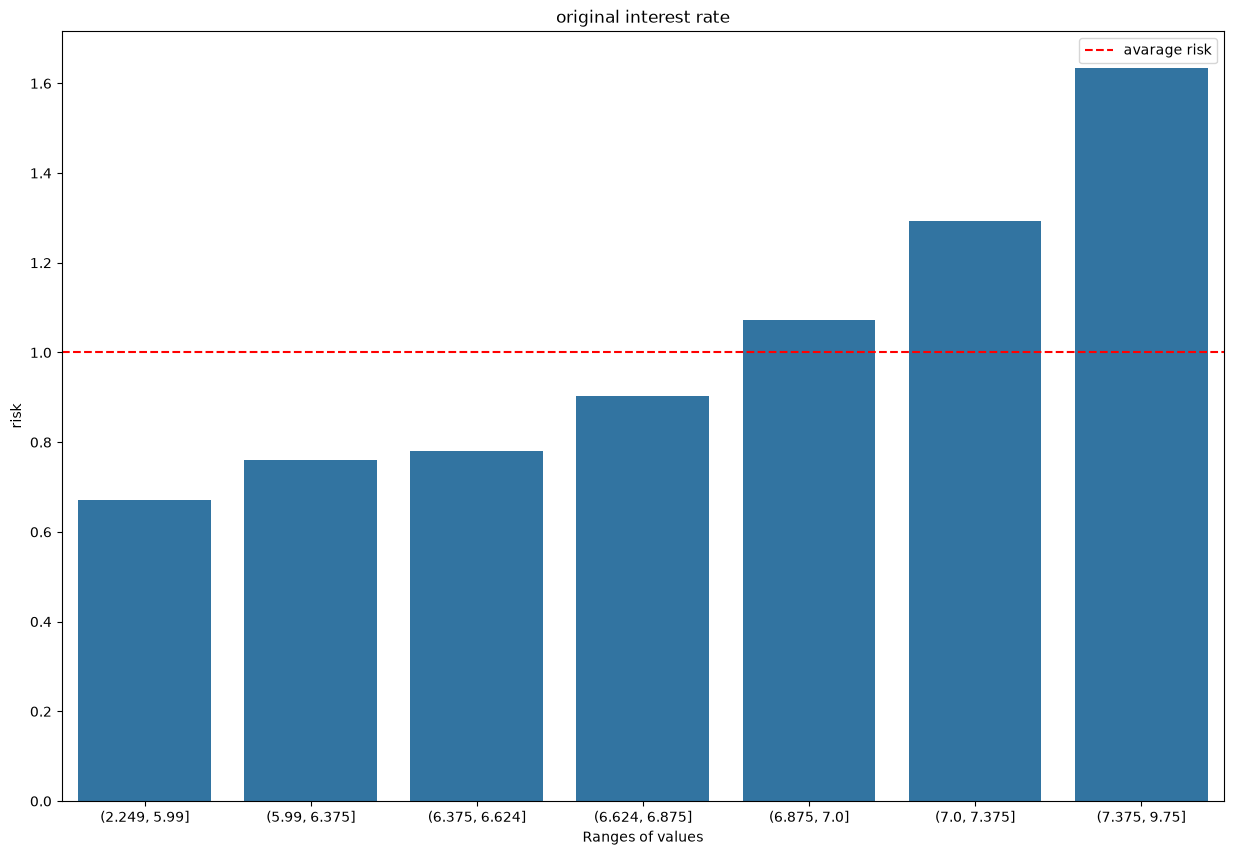

In [45]:

for col in numerical_columns:
    df = model_df[[col,"target_90plus"]].dropna().copy()
    df["bin"]= pd.qcut(
        model_df[col],
        q=7,
        duplicates="drop"
    )
    del df[col]
    df = df.groupby("bin").mean()
    df["risk"]=df/global_defective

    fig ,ax = plt.subplots(figsize=(15,10))
    sns.barplot(data=df,x=df.index , y=df.risk,ax=ax)
    ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
    ax.legend()
    plt.xlabel("Ranges of values")
    plt.title(col.replace("_"," "))
    

## Missing value risk

this feature sees to have a higher risk compard to default , we will consider that


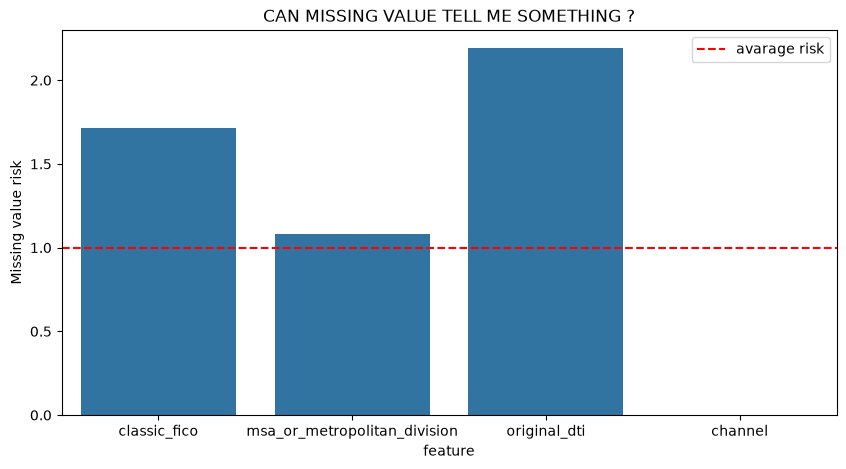

In [48]:
missing_risk = []
for col in columns:
    score = model_df_eda.iloc[model_df_eda[col].isnull(),:].target_90plus.mean()
    if not pd.isna(score):
        missing_risk.append((col,score/global_defective))

missing_risk_df = pd.DataFrame(missing_risk , columns=["feature","missing_risk"])

fig , ax = plt.subplots(figsize=(10,5))
sns.barplot(data=missing_risk_df,x=missing_risk_df["feature"],y=missing_risk_df["missing_risk"],ax=ax)
ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
ax.legend()
plt.ylabel("Missing value risk")
plt.title("CAN MISSING VALUE TELL ME SOMETHING ?")
print("this feature sees to have a higher risk compard to default , we will consider that")


## Mutual info and correlation analisys

Text(0, 0.5, 'Features')

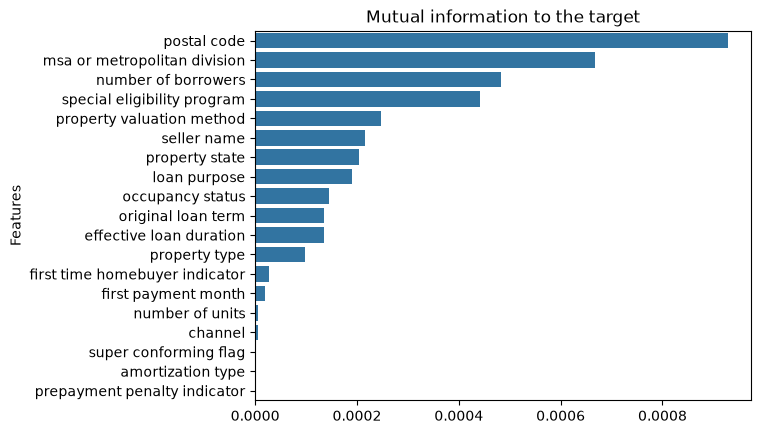

In [73]:
model_df_eda["msa_or_metropolitan_division"] = model_df_eda["msa_or_metropolitan_division"].fillna("NOT available")
model_df_eda["channel"] = model_df_eda["channel"].fillna("NOT available")


def get_mi(column):
    return mutual_info_score(column,model_df_eda.target_90plus)

mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)
mi.index=mi.index.str.replace("_"," ")
sns.barplot(mi,orient="h")
plt.title("Mutual information to the target")
plt.ylabel("Features")

Text(0, 0.5, 'Features')

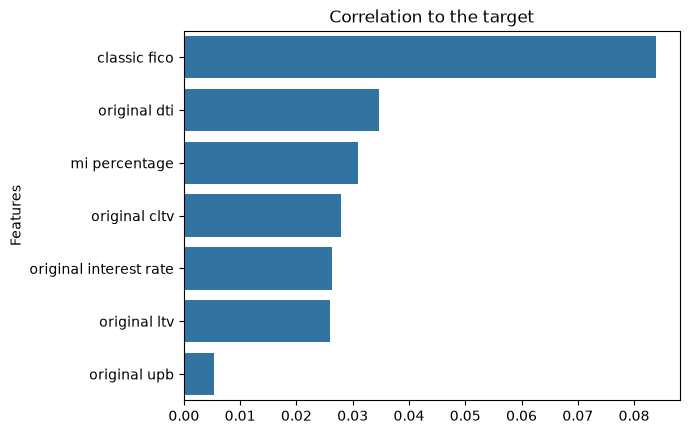

In [74]:
model_df_eda = model_df_eda.fillna(0)

correlation = model_df_eda[numerical_columns].corrwith(model_df_eda.target_90plus).abs().sort_values(ascending=False)
correlation.index=correlation.index.str.replace("_"," ")
sns.barplot(correlation,orient="h")
plt.title("Correlation to the target")
plt.ylabel("Features")

## Trying to create new features  

Text(0.5, 1.0, 'CREATING NEW FEATURES')

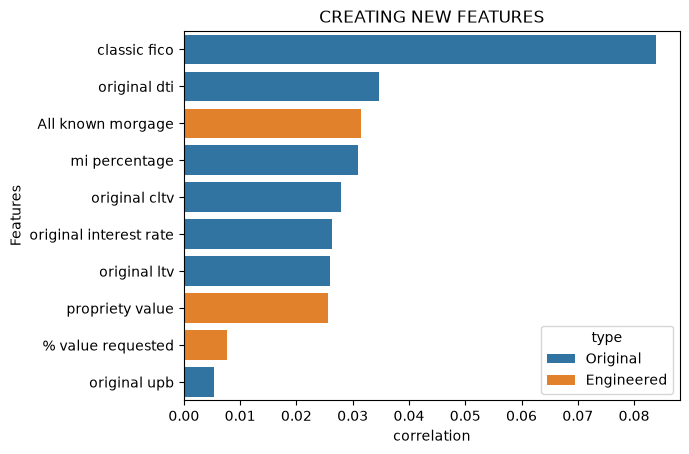

In [75]:
model_df_eda_try = model_df_eda.copy()
'''
def calc(P,r,n):
    numerator = ((1+r)**n)*r
    denominator = ((1+r)**n)-1
    return (numerator/denominator)*P*n

model_df_eda_try["total_amount"]=calc(model_df_eda_try["original_upb"],model_df_eda_try["original_interest_rate"],model_df_eda_try["effective_loan_duration"].astype("float64")).astype("float64")
'''
model_df_eda_try["propriety_value"]=model_df_eda_try["original_ltv"]/model_df_eda_try["original_upb"]
model_df_eda_try["All_known_morgage"]=model_df_eda_try["original_cltv"]*model_df_eda_try["propriety_value"]
model_df_eda_try["% value requested"]=model_df_eda_try["original_upb"]/model_df_eda_try["propriety_value"]

new_columns=["propriety_value","All_known_morgage","% value requested"]
correlation = model_df_eda_try[numerical_columns+new_columns].corrwith(model_df_eda_try.target_90plus).abs().sort_values(ascending=False)
is_original = (correlation.index.isin(numerical_columns).astype(int).tolist())

corr_plot = (
    correlation.rename_axis("Features").reset_index(name="correlation")
)
corr_plot["type"]= np.where(corr_plot["Features"].isin(numerical_columns),"Original","Engineered")
corr_plot["Features"]=corr_plot["Features"].str.replace("_"," ")
sns.barplot(data = corr_plot, x="correlation",y="Features",hue="type",dodge=False)
plt.title("CREATING NEW FEATURES")

In [ ]:
model_df_eda_try[numerical_columns].dtypes

classic_fico              float64
mi_percentage             float64
original_cltv             float64
original_dti              float64
original_upb              float64
original_ltv              float64
original_interest_rate    float64
dtype: object

## Correlation between features

Text(0.5, 1.0, 'Correlation between features\n')

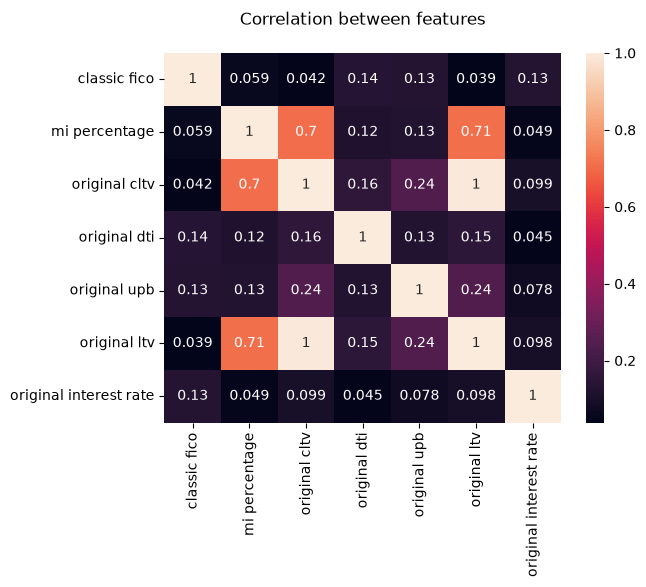

In [77]:
df_corr={}
for col in numerical_columns:
    correlation = model_df_eda[numerical_columns].corrwith(model_df_eda[col]).abs()
    df_corr[col]=correlation
df_corr = pd.DataFrame(df_corr)
df_corr.index=df_corr.index.str.replace("_"," ")
df_corr.columns=df_corr.columns.str.replace("_"," ")

sns.heatmap(data = df_corr ,annot=True)
plt.title("Correlation between features\n")

In [ ]:


'''
df_mi={}
for col in categorical_columns:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi
'''

'\ndf_mi={}\nfor col in categorical_columns:\n    def get_mi(column):\n        return mutual_info_score(column,model_df_eda[col])\n    mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)\n    df_mi[col]=mi\ndf_mi = pd.DataFrame(df_mi)\ndf_mi\n'

In [78]:
categorical_interesting=["msa_or_metropolitan_division","property_state","postal_code"]
df_mi={}
for col in categorical_interesting:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_interesting].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi

,msa_or_metropolitan_division,property_state,postal_code
msa_or_metropolitan_division,5.049031,3.015040,4.631775
postal_code,4.631775,3.477691,6.198959
property_state,3.015040,3.477705,3.477691


<Axes: title={'center': 'Mutual info between features\n'}>

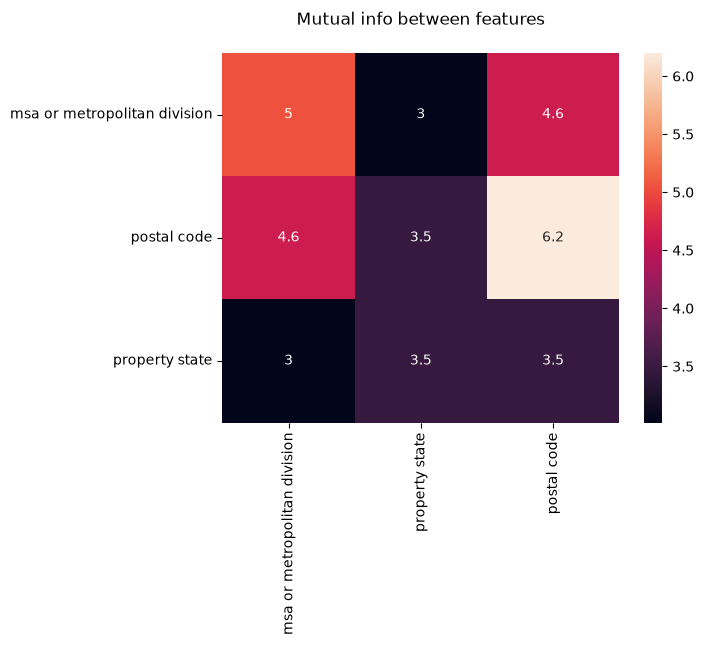

In [79]:
df_mi.index=df_mi.index.str.replace("_"," ")
df_mi.columns=df_mi.columns.str.replace("_"," ")
plt.title("Mutual info between features\n")
sns.heatmap(data=df_mi,annot=True)

# Validation Framework setup

In [80]:
date_col="first_payment_date"
X_train = model_df[
    (model_df[date_col] >= "2022-10-01") &
    (model_df[date_col] <  "2023-10-01")
].copy()

X_val = model_df[
    (model_df[date_col] >= "2023-10-01") &
    (model_df[date_col] <  "2024-01-01")
].copy()

X_test =  model_df[
    (model_df[date_col] >= "2024-01-01") &
    (model_df[date_col] <  "2024-04-01")
].copy()

X_full_train = pd.concat([X_train,X_val],ignore_index=True,axis=0)

X_train=X_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)
X_val=X_val.reset_index(drop=True)
X_full_train=X_full_train.reset_index(drop=True)

y_train = X_train["target_90plus"].values
y_test = X_test["target_90plus"].values
y_val = X_val["target_90plus"].values
y_full_train = X_full_train["target_90plus"].values

# carefull the target is sti
# all in the data sets


# Pipeline

In [83]:
# Feature engineering 
m=5
new_columns= ["position_combined","property_value","All_known_morgage"]

#Create new features
def new_features(X):
    X=X.copy()
    # New features
    X["property_value"]=X["original_ltv"]/X["original_upb"]
    X["All_known_morgage"]=X["original_cltv"]*X["property_value"]

    # Missing value indicator
    X["dti_was_missing"]=X["original_dti"].isnull().astype(int)
    X["fico_score_was_missing"]=X["classic_fico"].isnull().astype(int)
    
    X[new_columns[0]]=(
        X["postal_code"].fillna("Missing").astype(str)+
        "-"+
        X["msa_or_metropolitan_division"].fillna("Missing").astype(str)+
        "-"+
        X["property_state"].fillna("Missing").astype(str)
    )
    for column in categorical_columns+numerical_columns+new_columns:
        X[column] = X[column].astype(object)
        X.loc[X[column].isna(), column] = np.nan

    return X
feature_creator = FunctionTransformer(new_features,validate=False)

#numerical transformer
numerical_transformer = IterativeImputer(max_iter=10,random_state=1)

#categorical transformers
one_hot_pipeline = Pipeline(steps=[

    ("imputation",SimpleImputer(strategy="constant",fill_value="missing")),
    ("one_hot_encoding",OneHotEncoder(handle_unknown="ignore"))
])

target_pipeline = Pipeline(steps=[

    ("imputation",SimpleImputer(strategy="constant",fill_value="missing")),
    ("target",TargetEncoder(cv=m,random_state=1,target_type="binary"))

])

#All column transformer

column_transformer=ColumnTransformer(transformers=[
    ("numerical",numerical_transformer,numerical_columns+new_columns[1:2]),
    ("categorical one hot",one_hot_pipeline,one_hot_encoding_columns),
    ("catgorical target",target_pipeline,target_encoding_columns+new_columns)
])



# Model and feature selection

## Model selection

In [ ]:
logistic_regressor= LogisticRegression(random_state=1,max_iter=3000)

decision_tree = DecisionTreeClassifier(random_state=1,max_depth=20)

randomforest =  RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

models=[logistic_regressor,decision_tree,randomforest,xgb_model]



In [ ]:
overall_scores_= {}
calibration_curve_dict={}
for model in models:
    score_df= pd.Series()
    pipeline = Pipeline(steps=[
        ("new features",feature_creator),
        ("impute and encode",column_transformer),
        ("model",model)
    ])
    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict_proba(X_val)[:,1]

    score_df.loc["ROC-AUC"]=roc_auc_score(y_val,y_pred)
    score_df.loc["Avarage Precision"]=average_precision_score(y_val,y_pred)
    score_df.loc["Brier Score"]=brier_score_loss(y_val,y_pred)
    prob_true , prob_pred = calibration_curve(y_val,y_pred,n_bins=10,strategy="quantile")

    calibration_curve_dict["prob_true %s"%model.__class__.__name__]=prob_true
    calibration_curve_dict["prob_pred %s"%model.__class__.__name__]=prob_pred


    overall_scores_[model.__class__.__name__]=score_df

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling b

In [ ]:
overall_scores=overall_scores_.copy()
overall_scores = pd.DataFrame(overall_scores)

overall_scores["Baseline"]=[0.5,y_val.mean(),brier_score_loss(y_val,np.random.randint(0,2,len(y_val)))]
col = overall_scores.pop("Baseline")
overall_scores.insert(0,"Baseline",col)
overall_scores.round(4)

,Baseline,LogisticRegression,DecisionTreeClassifier,RandomForestClassifier,XGBClassifier
ROC-AUC,0.5000,0.8177,0.5813,0.8036,0.8264
Avarage Precision,0.0078,0.0321,0.0140,0.0272,0.0358
Brier Score,49.9991,0.0077,0.0195,0.0077,0.0077


In [ ]:

calibration_curve_df = pd.DataFrame({
    key: pd.Series(values)
    for key, values in calibration_curve_dict.items()
})
calibration_curve_df=calibration_curve_df.fillna(0)


In [ ]:
calibration_curve_df

,prob_true LogisticRegression,prob_pred LogisticRegression,prob_true DecisionTreeClassifier,prob_pred DecisionTreeClassifier,prob_true RandomForestClassifier,prob_pred RandomForestClassifier,prob_true XGBClassifier,prob_pred XGBClassifier
0,0.000236,0.000575,0.006784,0.000000,0.000236,0.001249,0.000142,0.000357
1,0.000520,0.001314,0.000675,0.000116,0.000283,0.002182,0.000283,0.000784
2,0.000472,0.002137,0.003591,0.000841,0.000567,0.003074,0.000803,0.001259
3,0.001512,0.003185,0.010417,0.004418,0.001937,0.004093,0.001512,0.001915
4,0.003118,0.004565,0.021589,0.150617,0.003496,0.005504,0.002598,0.002985
5,0.004015,0.006484,0.000000,0.000000,0.003968,0.007446,0.002645,0.004714
6,0.006755,0.009277,0.000000,0.000000,0.006755,0.009961,0.007274,0.007404
7,0.010061,0.013595,0.000000,0.000000,0.013792,0.013415,0.010769,0.011685
8,0.018139,0.021133,0.000000,0.000000,0.018044,0.018754,0.018470,0.018862
9,0.033348,0.045333,0.000000,0.000000,0.029096,0.035916,0.033678,0.043231


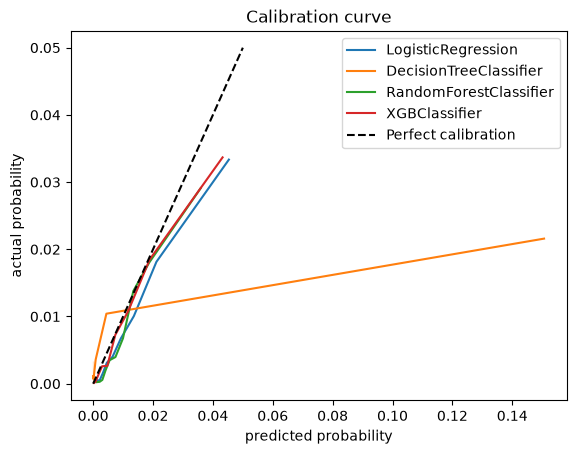

In [ ]:

for modelname in models:
    sns.lineplot(x=calibration_curve_df[f"prob_pred {modelname.__class__.__name__}"],y=calibration_curve_df[f"prob_true {modelname.__class__.__name__}"],label=modelname.__class__.__name__)
plt.xlabel("predicted probability")
plt.ylabel("actual probability")
plt.title("Calibration curve")
plt.plot([0,0.05],[0,0.05],linestyle="--",color="black",label="Perfect calibration")
plt.legend()


## Feature selection

In [ ]:
xgb_model_RFE = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

n_feature_scores = pd.Series()
for i in  [10]:

    selector = RFE(estimator=xgb_model_RFE,n_features_to_select=i,step=1)

    pipeline = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("selector",selector),
            ("model",xgb_model_RFE)

        ])
    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict_proba(X_val)[:,1]

    n_feature_scores.loc[i]=average_precision_score(y_val,y_pred)

     


/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


<Axes: >

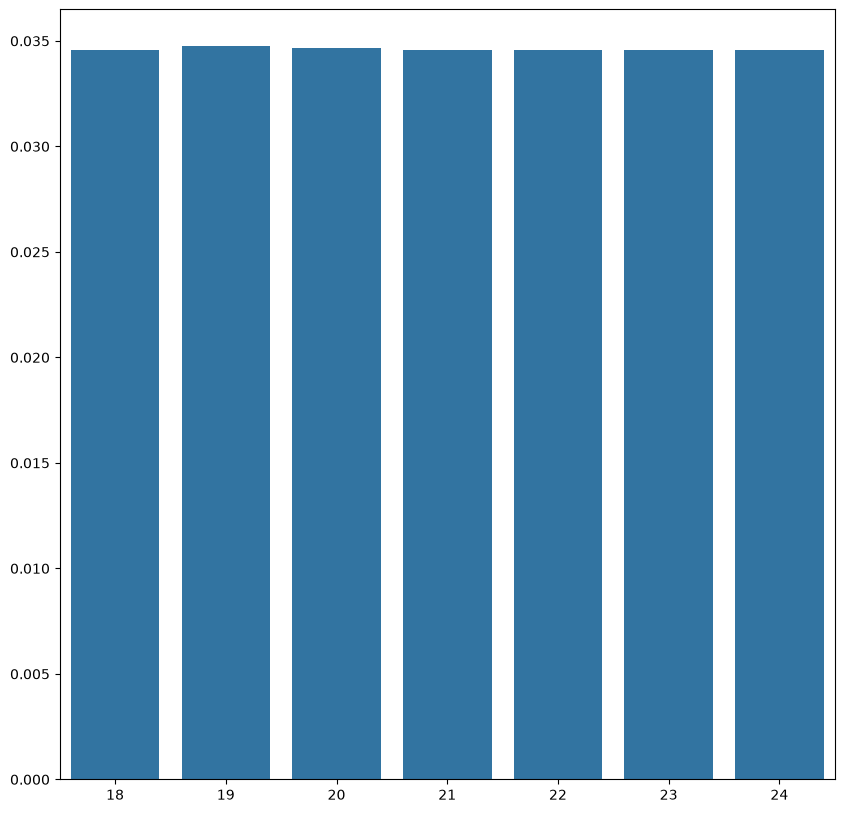

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(n_feature_scores)


In [ ]:
feature_names = pipeline.named_steps["impute and encode"].get_feature_names_out()

len(feature_names)

61

In [ ]:
selector= pipeline.named_steps["selector"]
selected_features=feature_names[selector.support_]
list(selected_features) 

['numerical__classic_fico',
 'numerical__original_cltv',
 'numerical__original_dti',
 'numerical__original_upb',
 'numerical__original_interest_rate',
 'categorical one hot__loan_purpose_P',
 'categorical one hot__number_of_borrowers_1',
 'catgorical target__msa_or_metropolitan_division',
 'catgorical target__property_state',
 'catgorical target__position_combined']

# Model tuning

In [ ]:
tuning_scores=[]
for i in[1]:
    for j in [1,2,3,4,5]:
        selector_tuned = RFE(estimator=xgb_model_RFE,n_features_to_select=10,step=10)

        xgb_model_tuned = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            min_child_weight=j,
            
            eval_metric="auc",
            random_state=42,
            n_jobs=-1
        )

        pipeline_tuned = Pipeline(steps=[
                    ("new features",feature_creator),
                    ("impute and encode",column_transformer),
                    ("selector",selector_tuned),
                    ("model",xgb_model_tuned)

                ])
        pipeline_tuned.fit(X_train,y_train)
        y_pred_tuning = pipeline_tuned.predict_proba(X_val)[:,1]

        tuning_scores.append((i,j,average_precision_score(y_val,y_pred_tuning)))



/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling b

In [ ]:
tuning_scores_ = tuning_scores.copy()

Text(0.5, 1.0, 'Model tuning , 100 rounds')

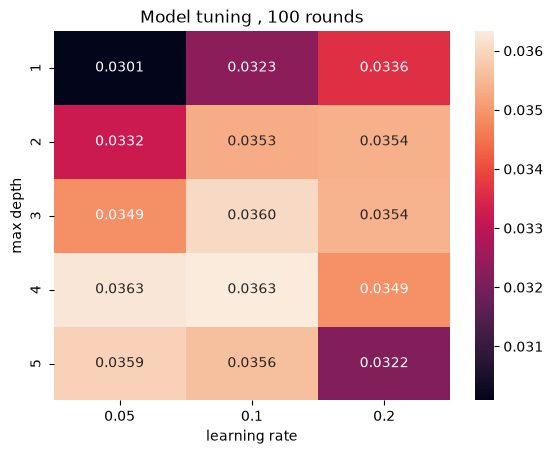

In [ ]:

tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","max depth","avarage precision"])
heatmap_data = tuning_scores_.pivot(
    index="max depth",
    columns="learning rate",
    values="avarage precision")
sns.heatmap(data=heatmap_data,annot=True,fmt=".4f")
plt.title("Model tuning , 100 rounds")

<Axes: xlabel='min child weight', ylabel='average precision'>

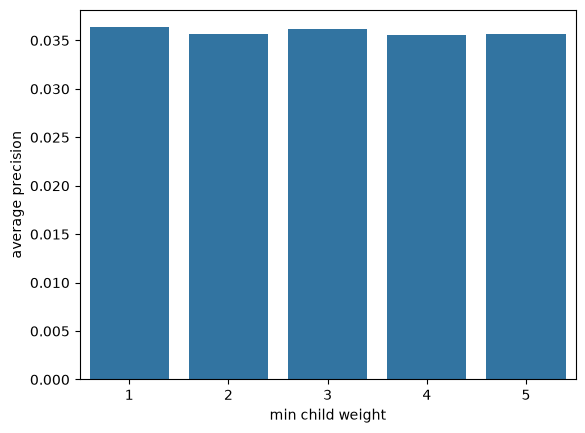

In [ ]:
tuning_scores_ = pd.DataFrame(tuning_scores_, columns=["learning rate","min child weight","average precision"])
bar_series = tuning_scores_.set_index("min child weight")["average precision"]
sns.barplot(bar_series)

# Final model ad threshold selection

## Final model and data

In [30]:
xgb_model_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=1,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

selector_final = RFE(estimator=xgb_model_final,n_features_to_select=10,step=1)
pipeline_final = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("selector",selector_final),
            ("model",xgb_model_final)

        ])

pipeline_final.fit(X_full_train,y_full_train)
y_pred = pipeline_final.predict_proba(X_test)[:,1]

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [16]:
prevalence = y_test.mean()
ap = average_precision_score(y_test, y_pred)

evaluation_metrics = pd.Series({
    "Positive prevalence": prevalence,
    "ROC-AUC": roc_auc_score(y_test, y_pred),
    "Average Precision": ap,
    "AP lift": ap / prevalence,
    "Brier Score": brier_score_loss(y_test, y_pred)
    #"Log Loss": log_loss(y_test, y_pred)
})

evaluation_metrics

Positive prevalence    0.007564
ROC-AUC                0.827519
Average Precision      0.030995
AP lift                4.097703
Brier Score            0.007576
dtype: float64

## Treshold tuning

In [17]:
threshold_dict={}
for t in np.linspace(0,0.19,101):
    prediction = (y_pred >= t).astype(int)
    treshold_series=pd.Series({
    "Precision":precision_score(y_test,prediction),
    "Recall":recall_score(y_test,prediction),
    "F1 score":f1_score(y_test,prediction),
    "f2 score":fbeta_score(y_test,prediction,beta=2),
    "Specificity":recall_score(y_test,prediction,pos_label=0)
    })
    threshold_dict[t]=treshold_series


    

,0.0000,0.0019,0.0038,0.0057,0.0076,0.0095,0.0114,0.0133,0.0152,0.0171,...,0.1729,0.1748,0.1767,0.1786,0.1805,0.1824,0.1843,0.1862,0.1881,0.1900
Precision,0.007564,0.011867,0.014551,0.016919,0.018922,0.020742,0.022413,0.024150,0.025887,0.027711,...,0.057895,0.058667,0.061453,0.059829,0.061224,0.062500,0.063830,0.062305,0.063898,0.065147
Recall,1.000000,0.967655,0.925427,0.893980,0.849955,0.798742,0.746631,0.698113,0.653190,0.612758,...,0.019766,0.019766,0.019766,0.018868,0.018868,0.018868,0.018868,0.017969,0.017969,0.017969
F1 score,0.015014,0.023446,0.028651,0.033210,0.037020,0.040434,0.043519,0.046685,0.049800,0.053024,...,0.029471,0.029570,0.029912,0.028689,0.028846,0.028986,0.029126,0.027894,0.028050,0.028169
f2 score,0.036709,0.056559,0.068449,0.078644,0.086875,0.093951,0.100051,0.106072,0.111722,0.117331,...,0.022765,0.022788,0.022869,0.021861,0.021898,0.021930,0.021962,0.020951,0.020986,0.021013
Specificity,0.000000,0.385879,0.522320,0.604110,0.664131,0.712592,0.751796,0.785001,0.812666,0.836140,...,0.997548,0.997583,0.997699,0.997740,0.997795,0.997843,0.997891,0.997939,0.997994,0.998035


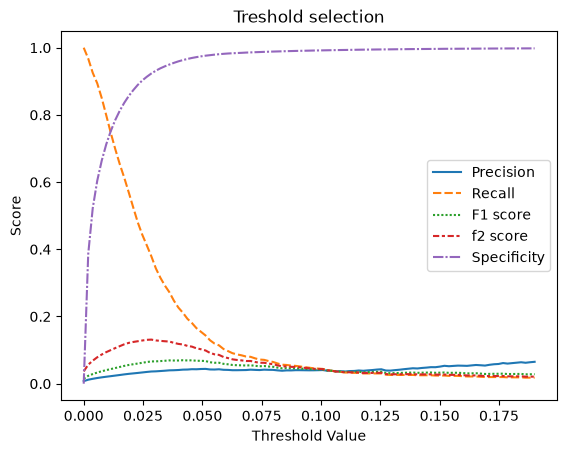

In [18]:
treshold_df = pd.DataFrame(threshold_dict)
sns.lineplot(treshold_df.T)
plt.xlabel("Threshold Value")
plt.ylabel("Score")
plt.title("Treshold selection")
treshold_df

In [19]:
metric = "f2 score"
f2_score = treshold_df.loc[metric,:].loc[treshold_df.loc[metric,:].idxmax()]
threshold = treshold_df.loc[metric,:].idxmax()
print(f"The maximum score for {metric} is {f2_score} and we take the threshold of {threshold}")

The maximum score for f2 score is 0.13123522826222167 and we take the threshold of 0.0285


In [20]:
prediction_final = (y_pred >= threshold).astype(int)

In [21]:
accuracy = (prediction_final == y_test).mean()
print(f"The accuracy of the model is {accuracy*100} %")
confusion_matrix_ = confusion_matrix(y_test,prediction_final)

print(f"\nTrue Positive {confusion_matrix_[0][0]}\tFalse positive {confusion_matrix_[0][1]}\n\nFalse negat {confusion_matrix_[1][0]}\t\tTrue negative {confusion_matrix_[1][1]}")

treshold_series_=pd.Series({
    "Precision":precision_score(y_test,prediction_final)*100,
    "Recall":recall_score(y_test,prediction_final)*100,
    "F1 score":f1_score(y_test,prediction_final),
    "f2 score":fbeta_score(y_test,prediction_final,beta=2),
    "Specificity":recall_score(y_test,prediction_final,pos_label=0)
    })
treshold_series_= pd.DataFrame(treshold_series_,columns=["scores"])
treshold_series_

The accuracy of the model is 91.91619208133417 %

True Positive 134829	False positive 11204

False negat 691		True negative 422


,scores
Precision,3.629795
Recall,37.915544
F1 score,0.066253
f2 score,0.131235
Specificity,0.923278


# Model explainability

## Permutation importance

In [22]:


xgb_model_pi = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=1,
    
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

pipeline_pi = Pipeline(steps=[
            ("new features",feature_creator),
            ("impute and encode",column_transformer),
            ("model",xgb_model_pi)

        ])
pipeline_pi.fit(X_test,y_test)

/Users/luca/ml-env/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('new features', ...), ('impute and encode', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['classic_fico','first_payment_date','first_time_homebuyer_indicator',..., 'target_90plus','first_payment_month','effective_loan_duration']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function new...t 0x14ebf8ae0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [26]:


result = sklearn_permutation_importance(
    estimator=pipeline_pi,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=1,
    n_jobs=-1
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)



KeyboardInterrupt: 

In [ ]:
importance_df.round(4)

,feature,importance,std
0,classic_fico,0.0481,0.0015
15,property_state,0.0195,0.0010
20,number_of_borrowers,0.0179,0.0017
3,msa_or_metropolitan_division,0.0166,0.0015
11,original_interest_rate,0.0153,0.0016
8,original_dti,0.0150,0.0013
7,original_cltv,0.0128,0.0021
17,postal_code,0.0125,0.0008
9,original_upb,0.0097,0.0024
12,channel,0.0053,0.0009


## SHAP values

In [38]:
shap.initjs()
model=pipeline_final.named_steps["model"]


# row data 
row_to_show = 82
row_data = X_test.iloc[[row_to_show]] 

#background data
background_data= X_full_train.sample(200,random_state=1)

#encode
encoded_data = pipeline_final[:-1].transform(row_data)
background_encoded = pipeline_final[:-1].transform(background_data)

#get names out
feature_names = (pipeline_final.named_steps["impute and encode"].get_feature_names_out())
rfe = pipeline_final.named_steps["selector"]

selected_names=feature_names[rfe.get_support()]

#encode names 

encoded_data = pd.DataFrame(encoded_data,columns=selected_names) 
background_encoded = pd.DataFrame(background_encoded,columns=selected_names) 



def predict_default_probability(X):
    X = pd.DataFrame(X, columns=selected_names)
    return model.predict_proba(X)[:, 1]

masker = shap.maskers.Independent(
    background_encoded,
    max_samples=100
)

explainer = shap.PermutationExplainer(
    predict_default_probability,
    masker,
    feature_names=selected_names.tolist()
)

shap_values = explainer(
    encoded_data,
    max_evals=2 * len(selected_names) + 1
)

shap.initjs()
print(f"Probability predicted is {predict_default_probability(encoded_data)[0]} %")
shap.plots.force(shap_values[0])

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Probability predicted is 0.061575841158628464 %


In [41]:
X_test.iloc[list(y_test).index(1),:].T

classic_fico                                    650.0
first_payment_date                2024-02-01 00:00:00
first_time_homebuyer_indicator                      1
msa_or_metropolitan_division                  21300.0
mi_percentage                                     0.0
number_of_units                                     1
occupancy_status                                    P
original_cltv                                   100.0
original_dti                                     30.0
original_upb                                  70000.0
original_ltv                                     78.0
original_interest_rate                           6.75
channel                                             R
prepayment_penalty_indicator                        0
amortization_type                                 FRM
property_state                                     NY
property_type                                      SF
postal_code                                       149
loan_purpose                

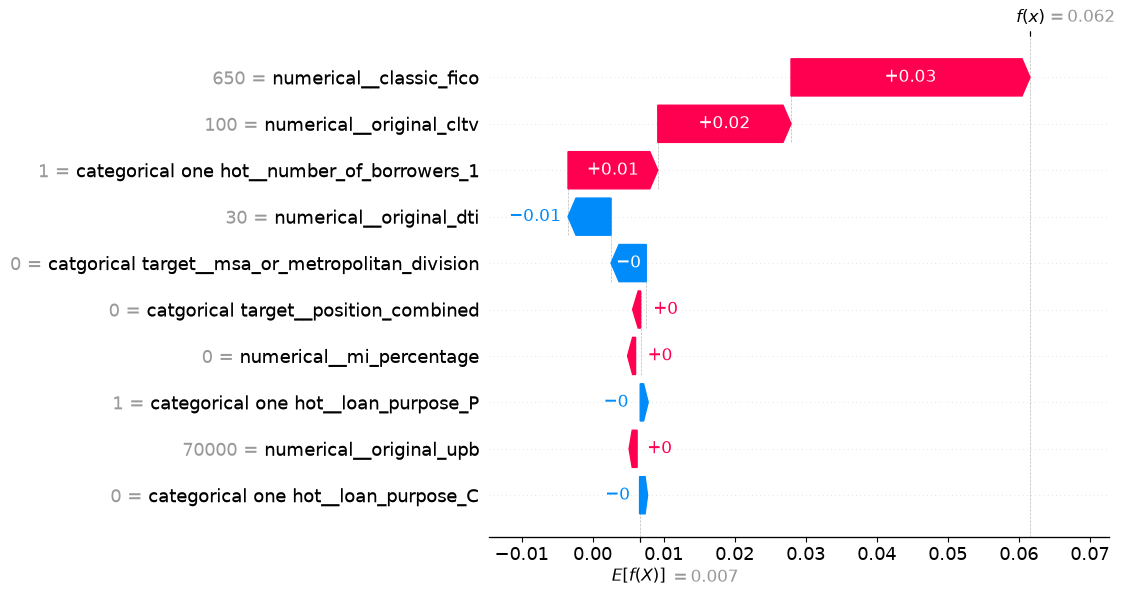

In [39]:
shap.plots.waterfall(shap_values[0],max_display=len(selected_names))